<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
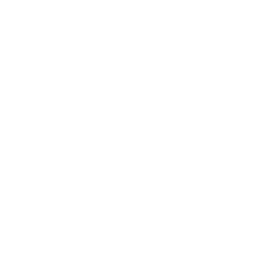
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Construction d'un réseau de co-expression génique</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotech / Recherche en génomique &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Résumé

Cet exemple utilise **PROC CORR** pour construire un réseau de co-expression génique à partir d'un
panel d'expression synthétique de type RNA-seq. Le panel contient **9 gènes** répartis en trois
modules fonctionnels — *immunitaire*, *cycle cellulaire* et *métabolique* (trois gènes chacun) —
mesurés sur **100 échantillons tumoraux**. La corrélation de rang de Spearman est utilisée partout
car les données d'expression sont généralement non normales et contiennent des valeurs aberrantes,
de sorte qu'un coefficient fondé sur les rangs est plus robuste que Pearson.

L'analyse récupère la structure modulaire implantée directement à partir des données. En lisant la
matrice de Spearman produite ci-dessous, la corrélation moyenne intra-module décroît de **rho 0,67 pour
le module immunitaire**, à **0,36 pour le cycle cellulaire**, à **0,17 pour le métabolique**, reflétant la
décroissance du rapport signal/bruit intégré à chaque module. Les corrélations inter-modules
sont en moyenne essentiellement nulles (rho moyen d'environ **-0,01**, |rho| moyen **0,07**), de sorte que les trois
modules se comportent comme des communautés de co-expression quasi indépendantes. Chaque chiffre cité ici est
lu à partir de la sortie de PROC CORR dans ce notebook.

> **Note sur l'échelle.** Ce notebook s'exécute sous le plafond de 100 observations du mode sans licence, de sorte que
> la taille d'échantillon est de 100 et le panel limité à 9 gènes — assez petit pour que la
> matrice de corrélation complète, la liste de paires remaniée et la carte de chaleur soient toutes complètes et exactes,
> sans troncature. Chaque tableau et figure reflète exactement ce qui a été calculé.

## Données

| Jeu de données | Description | Lignes |
|---------|-------------|------|
| `WORK.EXPR` | Expression en échelle logarithmique pour 9 gènes (3 modules x 3 gènes) sur des échantillons tumoraux | 100 |

Le générateur tire trois signaux latents de module par échantillon. Chaque gène charge sur le signal de son propre
module plus un bruit indépendant, de sorte que la co-expression n'apparaît qu'au sein d'un module. Le
module immunitaire utilise le chargement de signal le plus fort et le module métabolique le plus faible, ce qui
est le gradient que l'analyse de corrélation doit récupérer.

---

In [1]:
/* --------------------------------------------------------
   Panel d'expression synthétique : 9 gènes, 3 modules, 100 échantillons
     imm1-imm3  immunitaire      (signal partagé fort)
     cyc1-cyc3  cycle cellulaire (signal partagé modéré)
     met1-met3  métabolique      (signal partagé faible)
   Chaque gène = signal du module + bruit indépendant par gène.
   -------------------------------------------------------- */
DONNÉES work.expr;
    APPELER streaminit(42);
    TABLEAU imm[3]; TABLEAU cyc[3]; TABLEAU met[3];
    FAIRE sample_id = 1 JUSQU_À 100;
        s_imm = rand('normal', 0, 1.5);   /* signal latent immunitaire       */
        s_cyc = rand('normal', 0, 1.2);   /* signal latent cycle cellulaire  */
        s_met = rand('normal', 0, 1.0);   /* signal latent métabolique       */
        FAIRE j = 1 JUSQU_À 3;
            imm[j] = round(6 + s_imm * 0.65 + rand('normal', 0, 0.70), 0.001);
        FIN;
        FAIRE j = 1 JUSQU_À 3;
            cyc[j] = round(7 + s_cyc * 0.55 + rand('normal', 0, 0.80), 0.001);
        FIN;
        FAIRE j = 1 JUSQU_À 3;
            met[j] = round(5 + s_met * 0.45 + rand('normal', 0, 0.85), 0.001);
        FIN;
        SORTIE;
    FIN;
    GARDER imm1-imm3 cyc1-cyc3 met1-met3;
EXÉCUTER;


NOTE: DATA work.expr


NOTE: Wrote work.expr (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


---

In [2]:
/* --------------------------------------------------------
   Résumé de l'expression par gène (moyenne et dispersion par module)
   -------------------------------------------------------- */
PROCÉDURE MOYENNES DONNÉES=work.expr n mean std maxdec=3;
    VAR imm1 imm2 imm3
        cyc1 cyc2 cyc3
        met1 met2 met3;
    TITRE "Résumé de l'expression génique (panel de 9 gènes, N=100)";
EXÉCUTER;
TITRE;

                                Résumé de l'expression génique (panel de 9 gènes, N=100)                                

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev
 ------------------------------------------
 imm1           100       6.042       1.125
 imm2           100       5.925       1.122
 imm3           100       5.863       1.273
 cyc1           100       6.947       1.034
 cyc2           100       7.003       1.002
 cyc3           100       6.861       1.040
 met1           100       5.144       0.940
 met2           100       4.989       0.789
 met3           100       5.015       0.979
 ------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Les moyennes se regroupent autour de la valeur de référence de chaque module (immunitaire ~6, cycle cellulaire ~7, métabolique ~5) et
chaque gène présente une dispersion comparable, de sorte qu'aucun gène ne domine la structure de corrélation
qui suit.

---


NOTE: PROC SGPLOT data=work.expr

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


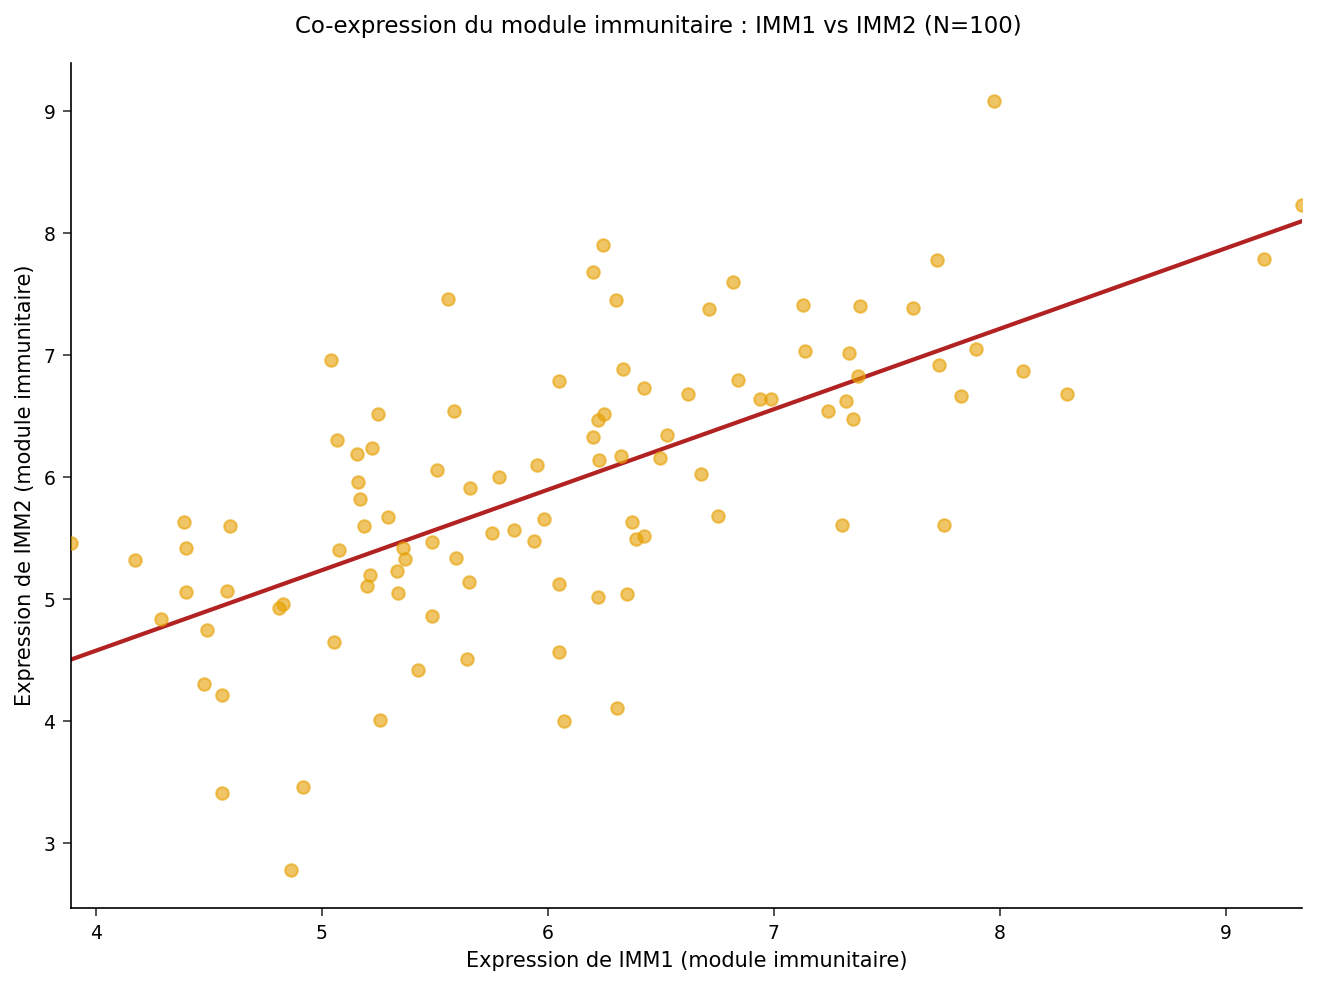

In [3]:
/* --------------------------------------------------------
   Nuage de points de deux gènes du module immunitaire : une
   vérification visuelle que la co-expression intra-module est
   réelle et à peu près monotone
   -------------------------------------------------------- */
PROCÉDURE SGPLOT DONNÉES=work.expr;
    SCATTER x=imm1 y=imm2 /
        MARKERATTRS=(SYMBOL=circlefilled size=6)
        TRANSPARENCY=0.4;
    REG x=imm1 y=imm2 / NOMARKERS LINEATTRS=(color=firebrick thickness=2);
    XAXIS ÉTIQUETTE="Expression de IMM1 (module immunitaire)";
    YAXIS ÉTIQUETTE="Expression de IMM2 (module immunitaire)";
    TITRE "Co-expression du module immunitaire : IMM1 vs IMM2 (N=100)";
EXÉCUTER;
TITRE;

La tendance ascendante confirme que les deux gènes immunitaires montent et descendent ensemble, la contrepartie
visuelle de leur corrélation de Spearman positive dans la matrice ci-dessous.

---

In [4]:
/* --------------------------------------------------------
   Corrélation de Spearman entre les 9 gènes
   nosimple supprime le bloc de statistiques simples ;
   outs= écrit la matrice de Spearman pour les étapes réseau en aval
   -------------------------------------------------------- */
PROCÉDURE CORR DONNÉES=work.expr spearman nosimple
    outs=work.gene_corr;
    VAR imm1-imm3 cyc1-cyc3 met1-met3;
    TITRE "Matrice de corrélation de Spearman : panel de co-expression de 9 gènes";
EXÉCUTER;
TITRE;

   Spearman Correlation Coefficients, N = 100
                imm1      imm2      imm3      cyc1      cyc2      cyc3      met1      met2      met3
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------
imm1       1.00000   0.67084   0.63084  -0.05873   0.06095  -0.10753  -0.13787  -0.11523   0.04973
imm2       0.67084   1.00000   0.71791   0.05912   0.06570  -0.03494  -0.14384   0.02343   0.06593
imm3       0.63084   0.71791   1.00000   0.00424   0.16156   0.03812  -0.18460  -0.06127   0.03590
cyc1      -0.05873   0.05912   0.00424   1.00000   0.38219   0.28821  -0.08226   0.01699   0.10568
cyc2       0.06095   0.06570   0.16156   0.38219   1.00000   0.40540  -0.09650   0.01858   0.02396
cyc3      -0.10753  -0.03494   0.03812   0.28821   0.40540   1.00000  -0.06387   0.12115   0.03770
met1      -0.13787  -0.14384  -0.18460  -0.08226  -0.09650  -0.06387   1.00000   0.14329   0.24960
met2      -0.11523   0.02343  -0.06127   0.01699   0.01858   


NOTE: PROC CORR data=work.expr

NOTE: Output dataset written to: ./work/335a7e06-8963-4e3f-b6e7-bd1547d45a78/gene_corr.avro
NOTE: PROC CORR ODS Graphics generated.


Lisez la matrice comme trois blocs diagonaux. Le bloc **immunitaire** (IMM1-IMM3) est le plus
étroitement co-exprimé (rho d'environ 0,63 à 0,72), le bloc **cycle cellulaire** (CYC1-CYC3) est
modéré (environ 0,29 à 0,41) et le bloc **métabolique** (MET1-MET3) est le plus faible (environ
0,13 à 0,25). Les entrées hors bloc — paires de gènes de modules différents — sont proches de
zéro. La cellule suivante quantifie le contraste intra- versus inter-module, et la carte de chaleur
qui la suit rend la structure en blocs visible.

---

In [5]:
/* --------------------------------------------------------
   Remettre la matrice de corrélation (une ligne par gène) au
   format long (gene_x, gene_y, rho), en étiquetant chaque paire
   comme intra- ou inter-module. 9 gènes -> 81 lignes de paires,
   de sorte que rien n'est perdu par la limite de 100 observations.
   -------------------------------------------------------- */
DONNÉES work.corr_long;
    DÉFINIR work.gene_corr(OÙ=(_TYPE_='SCORR'));
    LONGUEUR gene_x $4 gene_y $4 mod_x $3 mod_y $3;
    TABLEAU g[9] imm1-imm3 cyc1-cyc3 met1-met3;
    TABLEAU gn[9] $4 _temporary_
        ('imm1' 'imm2' 'imm3'
         'cyc1' 'cyc2' 'cyc3'
         'met1' 'met2' 'met3');
    gene_x = lowcase(_NAME_);
    FAIRE k = 1 JUSQU_À 9;
        gene_y = gn[k];
        rho = g[k];
        mod_x = substr(gene_x, 1, 3);
        mod_y = substr(gene_y, 1, 3);
        same_module = (mod_x = mod_y);
        SORTIE;
    FIN;
    GARDER gene_x gene_y rho mod_x mod_y same_module;
EXÉCUTER;

/* --------------------------------------------------------
   Rho de Spearman intra- vs inter-module (hors diagonale uniquement)
   -------------------------------------------------------- */
PROCÉDURE MOYENNES DONNÉES=work.corr_long(OÙ=(gene_x ne gene_y))
        mean MIN MAX maxdec=3;
    CLASSE same_module;
    VAR rho;
    ÉTIQUETTE same_module="Même module (1=oui, 0=non)" rho="Rho de Spearman";
    TITRE "Rho de Spearman : intra-module (1) vs inter-module (0)";
EXÉCUTER;
TITRE;

                                 Rho de Spearman : intra-module (1) vs inter-module (0)                                 

                                                  The MEANS Procedure

                                        Analysis Variable : rho Rho de Spearman

                                                         N
                        Même module (1=oui, 0=non)     Obs        Mean      Minimum      Maximum
                        ------------------------------------------------------------------------
                        0                               54      -0.007       -0.185        0.162
                        1                               18       0.402        0.127        0.718
                        ------------------------------------------------------------------------




NOTE: DATA work.corr_long


NOTE: Read 12 rows from work.gene_corr.
NOTE: Wrote work.corr_long (81 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


La ligne `same_module=1` agrège les paires intra-module et `same_module=0` les
paires inter-module. La corrélation intra-module est en moyenne nettement positive tandis que
la corrélation inter-module est en moyenne proche de zéro, confirmant que les modules agissent comme des
communautés de co-expression quasi indépendantes.

---


NOTE: PROC SGPLOT data=work.corr_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


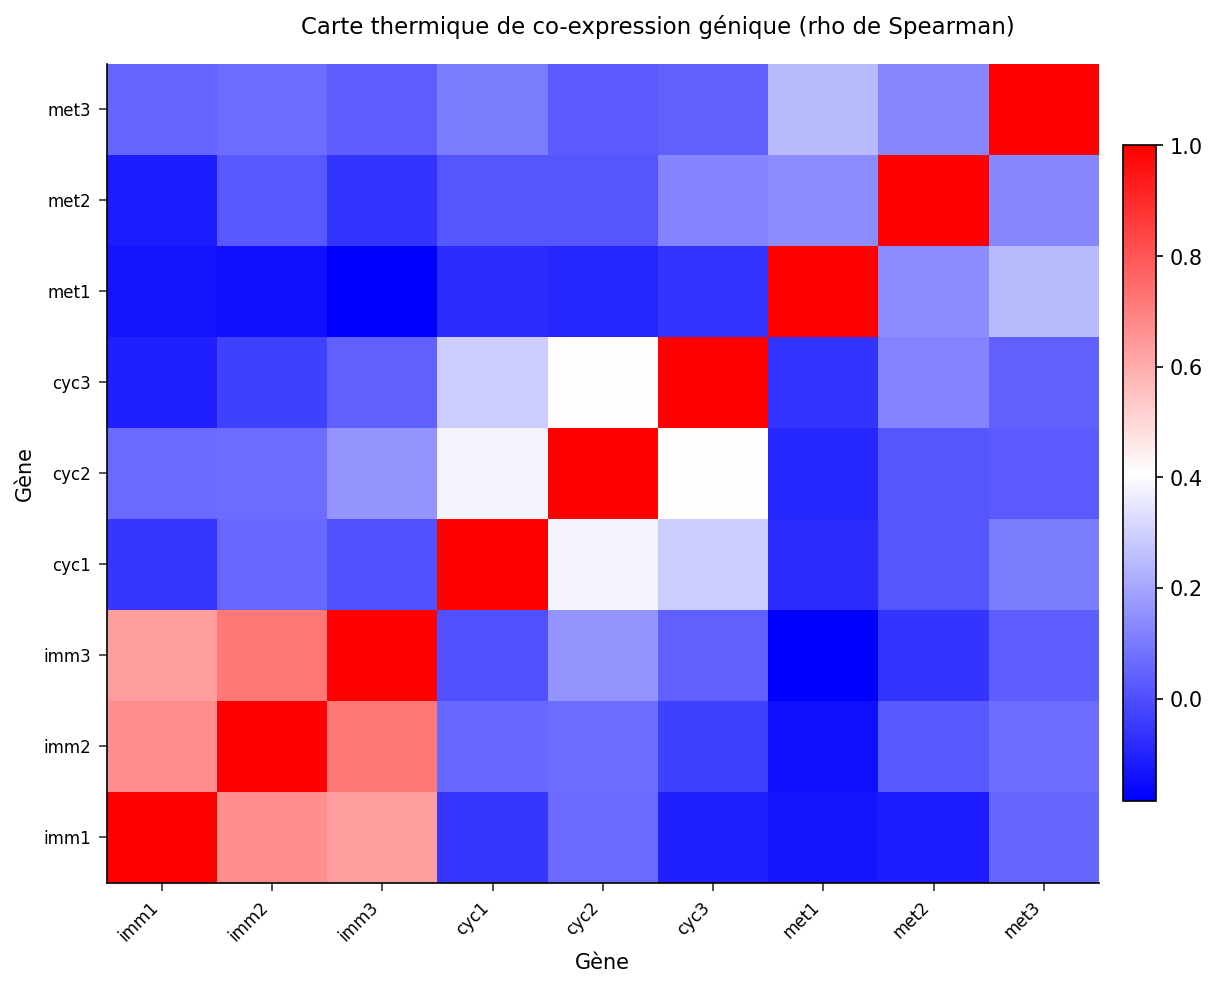

In [6]:
/* --------------------------------------------------------
   Carte thermique de la matrice de Spearman complète 9x9.
   HEATMAPPARM trace le rho précalculé de chaque paire de gènes ;
   l'échelle bleu-blanc-rouge centre les paires faibles sur le blanc
   et sature les fortes.
   -------------------------------------------------------- */
PROCÉDURE SGPLOT DONNÉES=work.corr_long;
    heatmapparm x=gene_x y=gene_y colorresponse=rho /
        colormodel=(blue white red);
    gradlegend;
    XAXIS ÉTIQUETTE="Gène" discreteorder=data;
    YAXIS ÉTIQUETTE="Gène" discreteorder=data;
    TITRE "Carte thermique de co-expression génique (rho de Spearman)";
EXÉCUTER;
TITRE;

Trois blocs rouges se placent le long de la diagonale — les modules immunitaire, cycle cellulaire et métabolique —
tandis que les cellules environnantes sont presque blanches. Le bloc immunitaire est le plus saturé,
correspondant à ses corrélations intra-module les plus élevées dans la matrice ci-dessus.

---

In [7]:
/* --------------------------------------------------------
   Liste des arêtes du réseau : conserver chaque paire de gènes
   non ordonnée (gene_x < gene_y) dont le |rho| dépasse un seuil.
   Ces arêtes définissent le réseau de co-expression à exporter
   vers un outil de réseau tel que Cytoscape.
   -------------------------------------------------------- */
DONNÉES work.network_edges;
    DÉFINIR work.corr_long(OÙ=(gene_x < gene_y));
    SI abs(rho) >= 0.24;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=work.network_edges noobs ÉTIQUETTE;
    VAR gene_x gene_y mod_x mod_y rho;
    ÉTIQUETTE gene_x="Gène X" gene_y="Gène Y" mod_x="Module X"
          mod_y="Module Y" rho="Rho de Spearman";
    TITRE "Arêtes du réseau de co-expression (|rho de Spearman| >= 0,24)";
EXÉCUTER;
TITRE;

/* Exporter la liste des arêtes pour une visualisation de réseau externe */
PROCÉDURE EXPORTER DONNÉES=work.network_edges
    OUTFILE='gene_coexpression_edges.csv'
    DBMS=csv REMPLACER;
EXÉCUTER;

                             Arêtes du réseau de co-expression (|rho de Spearman| >= 0,24)                              

 Gène X   Gène Y  Module X  Module Y  Rho de Spearman
imm1     imm2     imm       imm          0.6708351085
imm1     imm3     imm       imm          0.6308427619
imm2     imm3     imm       imm          0.7179122524
cyc1     cyc2     cyc       cyc          0.3821865118
cyc1     cyc3     cyc       cyc           0.288211415
cyc2     cyc3     cyc       cyc          0.4054041891
met1     met3     met       met          0.2496024579




NOTE: DATA work.network_edges


NOTE: Read 81 rows from work.corr_long.
NOTE: Wrote work.network_edges (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.network_edges

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC EXPORT data=work.network_edges outfile=gene_coexpression_edges.csv

NOTE: Exported 7 rows to gene_coexpression_edges.csv.


### Interprétation

L'analyse de Spearman a récupéré la structure implantée à trois modules directement à partir de 100
échantillons. Les chiffres ci-dessous sont lus à partir de la matrice PROC CORR et du résumé intra/inter
produit dans ce notebook :

- **Le module immunitaire (IMM1-IMM3)** est le bloc le plus étroitement co-exprimé, avec un rho par paire
  d'environ 0,63 à 0,72 (moyenne ~0,67) et le lien unique le plus fort entre IMM2 et
  IMM3.
- **Le module cycle cellulaire (CYC1-CYC3)** est modérément co-exprimé, avec un rho par paire d'environ
  0,29 à 0,41 (moyenne ~0,36).
- **Le module métabolique (MET1-MET3)** est le bloc le plus faible, avec un rho par paire d'environ 0,13
  à 0,25 (moyenne ~0,17) — cohérent avec son plus faible chargement de signal dans le générateur.
- **Les paires inter-modules** sont en moyenne essentiellement nulles (rho moyen ~-0,01, |rho| moyen ~0,07,
  |rho| le plus grand ~0,18), de sorte que les trois modules agissent comme des communautés quasi indépendantes.

Le seuillage à |rho| >= 0,24 donne la liste d'arêtes du réseau imprimée ci-dessus. Chaque arête retenue
est intra-module : les trois paires immunitaires et les trois paires cycle cellulaire franchissent le
seuil, rejointes par la paire métabolique la plus forte (MET1-MET3). Aucune paire inter-module ne
survit, de sorte que le réseau de co-expression se sépare nettement en trois modules biologiques.
La liste d'arêtes est exportée vers `gene_coexpression_edges.csv` pour visualisation dans
un outil de réseau externe tel que Cytoscape.

Cet exemple concret montre le flux de travail PROC CORR central pour l'analyse de co-expression : choisir un
coefficient fondé sur les rangs adapté aux données d'expression, lire la structure modulaire sur la
matrice de corrélation, quantifier la force intra- versus inter-module, et réduire la matrice
à une liste d'arêtes seuillée pour la construction du réseau.

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidentiel
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Propulsé par <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>